In [1]:
## Libraries Import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import re
import string


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
## Load Dataset

df = pd.read_csv("IMDB_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (50000, 2)


In [3]:
## Inspect Dataset

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.columns.tolist())

['review', 'sentiment']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 418


In [8]:
## Sentiment Distribution

df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

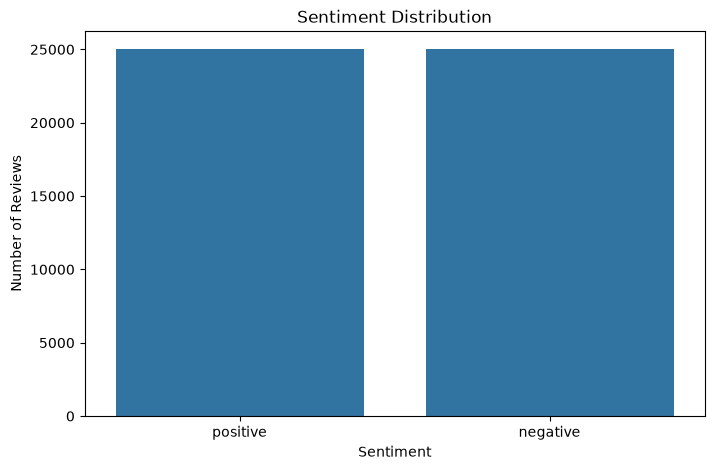

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='sentiment')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
### Observation

The dataset contains positive and negative movie reviews. The sentiment distribution is examined to determine whether the dataset is balanced across the two sentiment classes.

In [14]:
## Clean the Review Text


def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [16]:
df['clean_review'] = df['review'].apply(clean_text)

In [17]:
print("Original Review:")
print(df['review'].iloc[0])

print("\nCleaned Review:")
print(df['clean_review'].iloc[0])

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [19]:
## Convert Sentiment to Numeric Labels

df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [21]:
df[['sentiment', 'label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [22]:
df['label'].value_counts()

label
1    25000
0    25000
Name: count, dtype: int64

In [23]:
## Train/Test Split


X = df['clean_review']
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [24]:
## TF-IDF Vectorization


tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2)
)

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [26]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (40000, 10000)
Testing TF-IDF shape: (10000, 10000)


In [27]:
## Train Logistic Regression Model


model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [28]:
## Make Predictions
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [30]:
## Accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8977
Accuracy: 89.77%


In [31]:
## Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



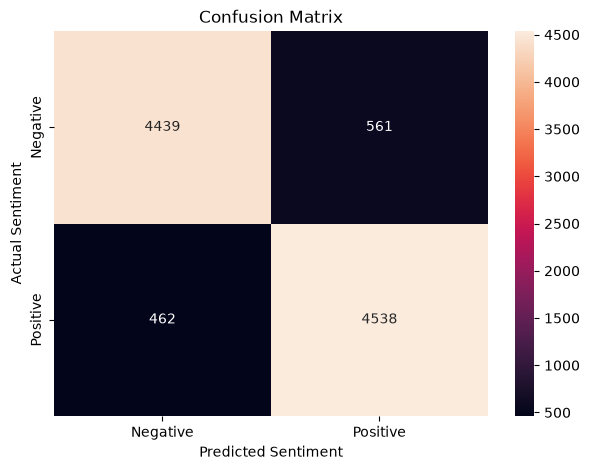

In [32]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)


plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')


plt.show()

In [ ]:
### Confusion Matrix Interpretation

The confusion matrix shows the number of correctly and incorrectly classified positive and negative re

In [34]:
## Test Your Own Reviews


def predict_sentiment(review):
    cleaned = clean_text(review)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [38]:
reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "The movie was boring, disappointing and a complete waste of time.",
    "Excellent acting and a fantastic story.",
    "I love Fareeha but She hate me too much"
]

for review in reviews:
    print("Review:", review)
    print("Prediction:", predict_sentiment(review))
    print()

Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive

Review: The movie was boring, disappointing and a complete waste of time.
Prediction: Negative

Review: Excellent acting and a fantastic story.
Prediction: Positive

Review: I love Fareeha but She hate me too much
Prediction: Positive



In [ ]:
## Conclusion

A sentiment analysis model was developed using the IMDB movie review dataset. The review text was cleaned and transformed into numerical features using TF-IDF vectorization. Logistic Regression was trained on the transformed text data and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The model was also tested on new review examples to demonstrate its ability to classify unseen text as positive or negative sentiment.